In [60]:
# ============================================
# CUSTOMER CHURN PREDICTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [61]:
file_path = r"C:\Users\yousr\OneDrive\Desktop\CUSTOMER CHURN\Churn_Modelling.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 14)


In [62]:
df = pd.read_csv("Churn_Modelling.csv")

In [63]:
# First five rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [64]:
# Dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 14


In [65]:
# Column names
print(df.columns.tolist())

['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [66]:
# Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [67]:
# Statistical summary
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [68]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
Series([], dtype: int64)


In [69]:
# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage[missing_percentage > 0])

Series([], dtype: float64)


In [70]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [71]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10000, 14)


In [72]:
print(df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [73]:
# Churn percentages
churn_percentage = df["Exited"].value_counts(normalize=True) * 100

print(churn_percentage)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


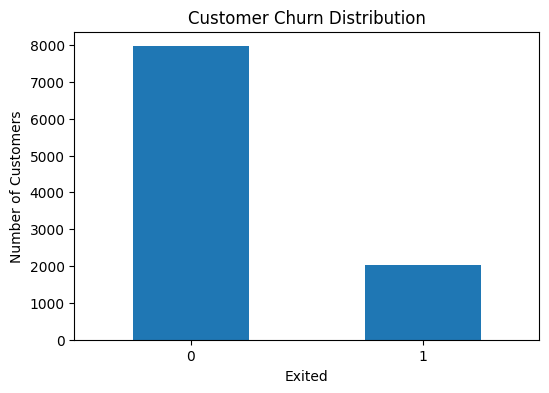

In [74]:
plt.figure(figsize=(6, 4))

df["Exited"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [75]:
gender_churn = pd.crosstab(
    df["Gender"],
    df["Exited"],
    normalize="index"
) * 100

print(gender_churn)

Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928


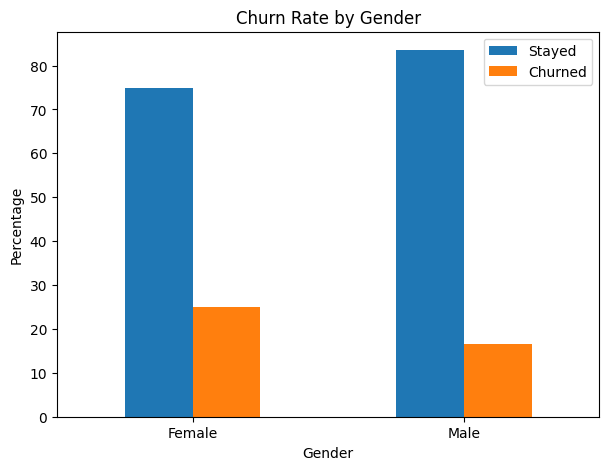

In [76]:
gender_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])

plt.show()

In [77]:
geography_churn = pd.crosstab(
    df["Geography"],
    df["Exited"],
    normalize="index"
) * 100

print(geography_churn)

Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395


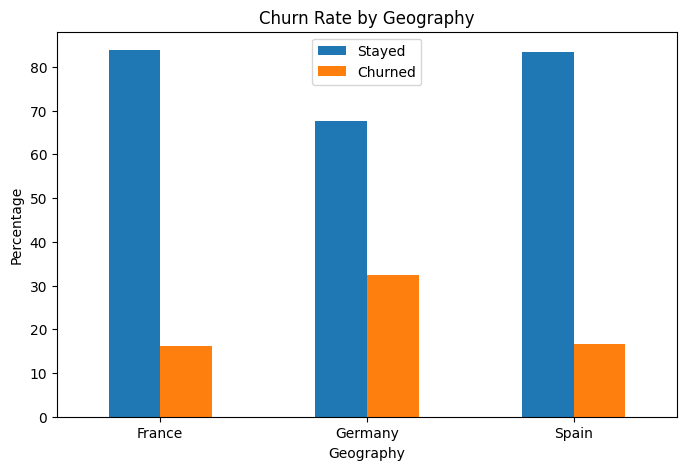

In [78]:
geography_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])

plt.show()

In [79]:
active_churn = pd.crosstab(
    df["IsActiveMember"],
    df["Exited"],
    normalize="index"
) * 100

print(active_churn)

Exited                  0          1
IsActiveMember                      
0               73.149103  26.850897
1               85.730926  14.269074


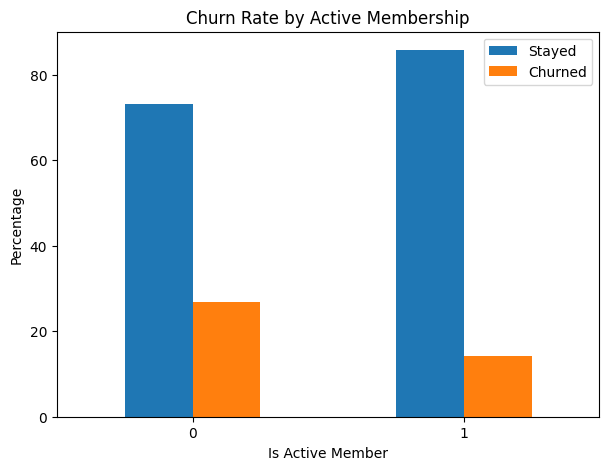

In [80]:
active_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Active Membership")
plt.xlabel("Is Active Member")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])

plt.show()

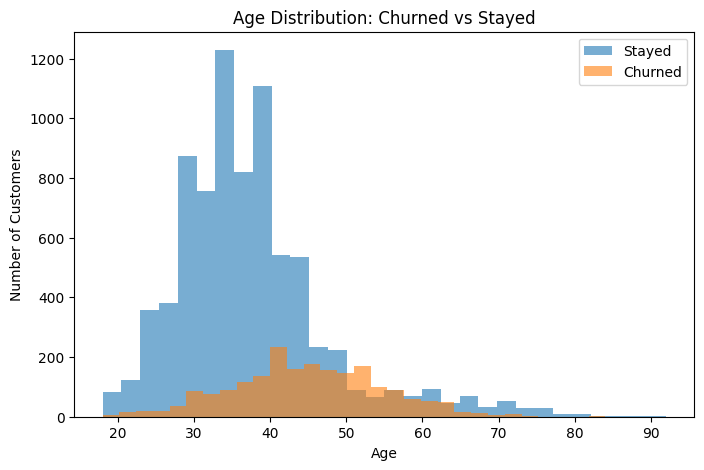

In [81]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Exited"] == 0]["Age"],
    bins=30,
    alpha=0.6,
    label="Stayed"
)

plt.hist(
    df[df["Exited"] == 1]["Age"],
    bins=30,
    alpha=0.6,
    label="Churned"
)

plt.title("Age Distribution: Churned vs Stayed")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()

plt.show()

In [82]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

correlation = df[numeric_columns].corr()

correlation["Exited"].sort_values(ascending=False)

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
CustomerId        -0.006248
HasCrCard         -0.007138
Tenure            -0.014001
RowNumber         -0.016571
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64

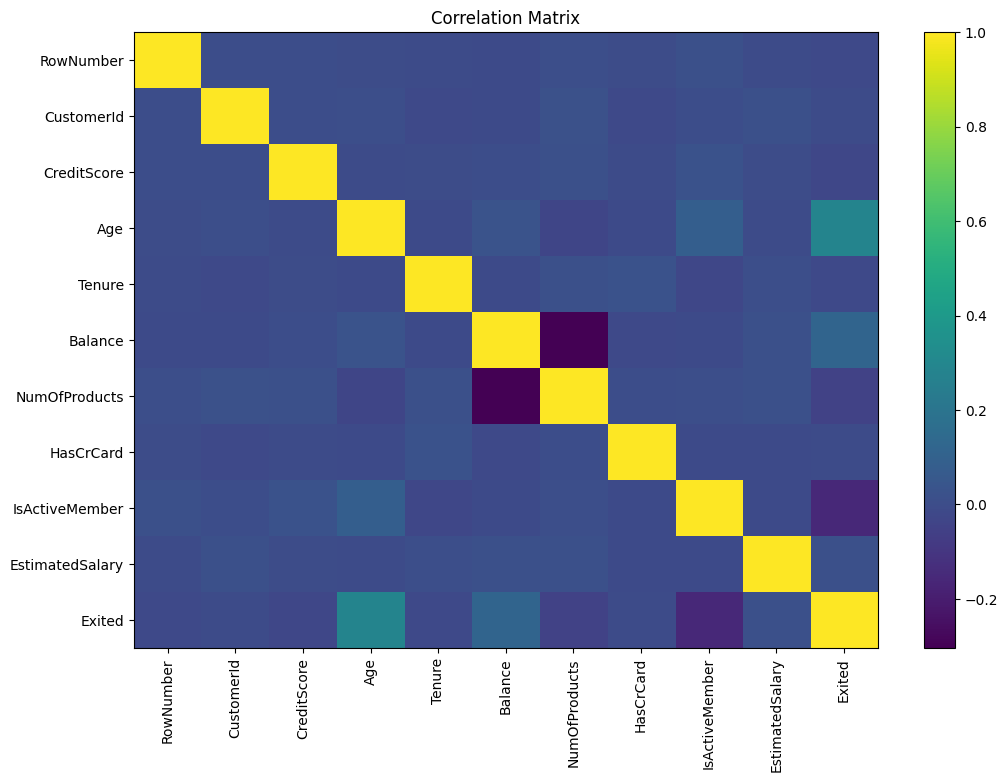

In [83]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.show()

In [84]:
df_model = df.drop(
    columns=["RowNumber", "CustomerId", "Surname"],
    errors="ignore"
)

df_model.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [85]:
X = df_model.drop("Exited", axis=1)

y = df_model["Exited"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 10)
Target: (10000,)


In [86]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Geography', 'Gender']

Numerical features:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8000, 10)
Testing set: (2000, 10)


In [88]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [89]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [90]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [91]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [92]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [93]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [94]:
y_pred_gb = gradient_boosting_model.predict(X_test)

y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [95]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

In [96]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        y_pred_gb,
        y_prob_gb
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8080,0.589147,0.186732,0.283582,0.774756
1,Random Forest,0.8635,0.770161,0.469287,0.583206,0.853508
2,Gradient Boosting,0.8720,0.798419,0.496314,0.612121,0.870911


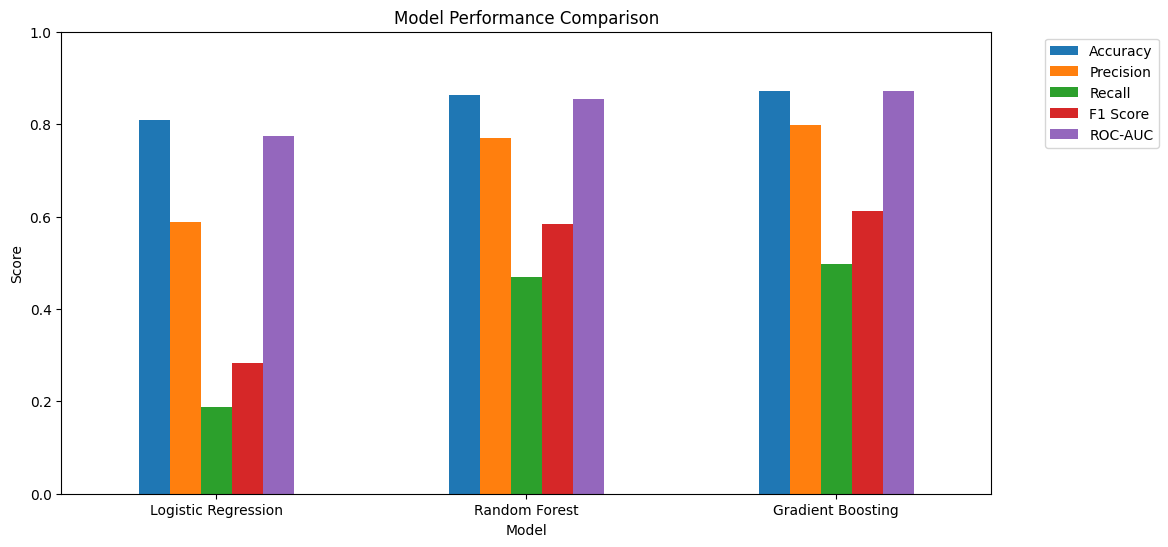

In [97]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

In [98]:
print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [99]:
print("RANDOM FOREST")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [100]:
print("GRADIENT BOOSTING")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000



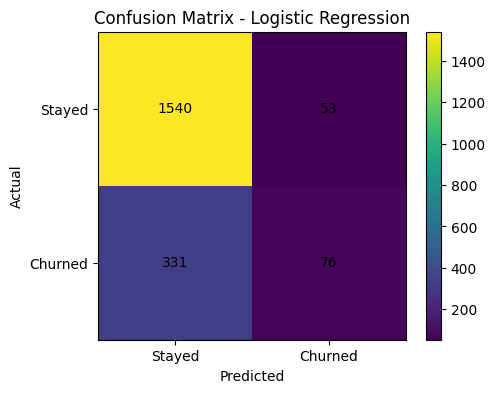

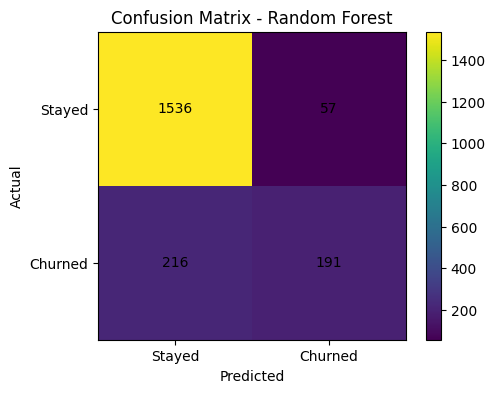

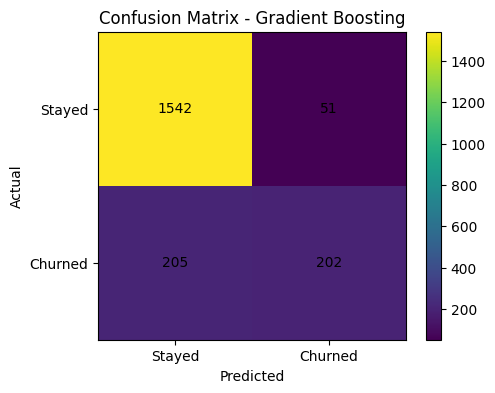

In [101]:
models_predictions = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

for model_name, predictions in models_predictions.items():
    
    cm = confusion_matrix(y_test, predictions)
    
    plt.figure(figsize=(5, 4))
    
    plt.imshow(cm)
    plt.colorbar()
    
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.xticks([0, 1], ["Stayed", "Churned"])
    plt.yticks([0, 1], ["Stayed", "Churned"])
    
    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )
    
    plt.show()

<Figure size 900x600 with 0 Axes>

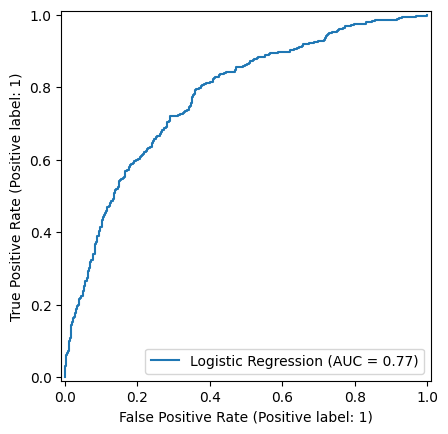

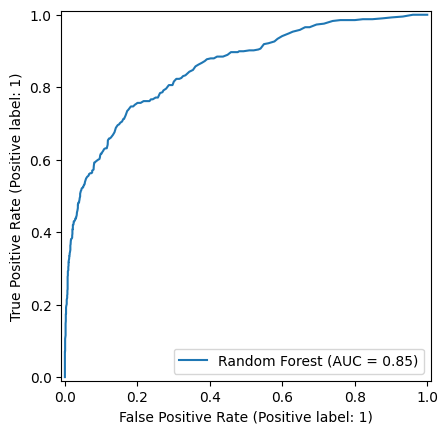

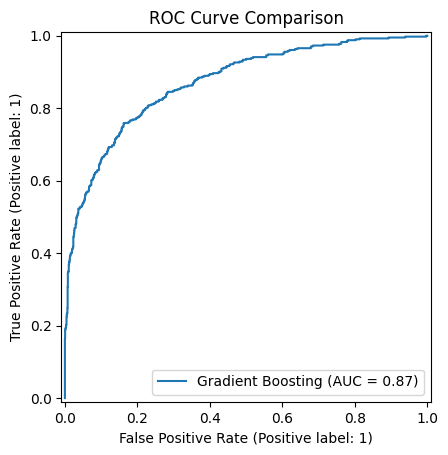

In [102]:
plt.figure(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_gb,
    name="Gradient Boosting"
)

plt.title("ROC Curve Comparison")

plt.show()

In [103]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on F1 Score:", best_model_name)

Best model based on F1 Score: Gradient Boosting


In [104]:
best_auc_model = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

print("Best model based on ROC-AUC:", best_auc_model)

Best model based on ROC-AUC: Gradient Boosting


In [105]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]

rf_classifier = random_forest_model.named_steps["classifier"]

feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_classifier.feature_importances_

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(20)

,Feature,Importance
1,num__Age,0.237503
7,num__EstimatedSalary,0.147119
0,num__CreditScore,0.142947
3,num__Balance,0.142377
4,num__NumOfProducts,0.128088
2,num__Tenure,0.081545
6,num__IsActiveMember,0.040445
8,cat__Geography_Germany,0.028709
5,num__HasCrCard,0.019218
10,cat__Gender_Male,0.018368


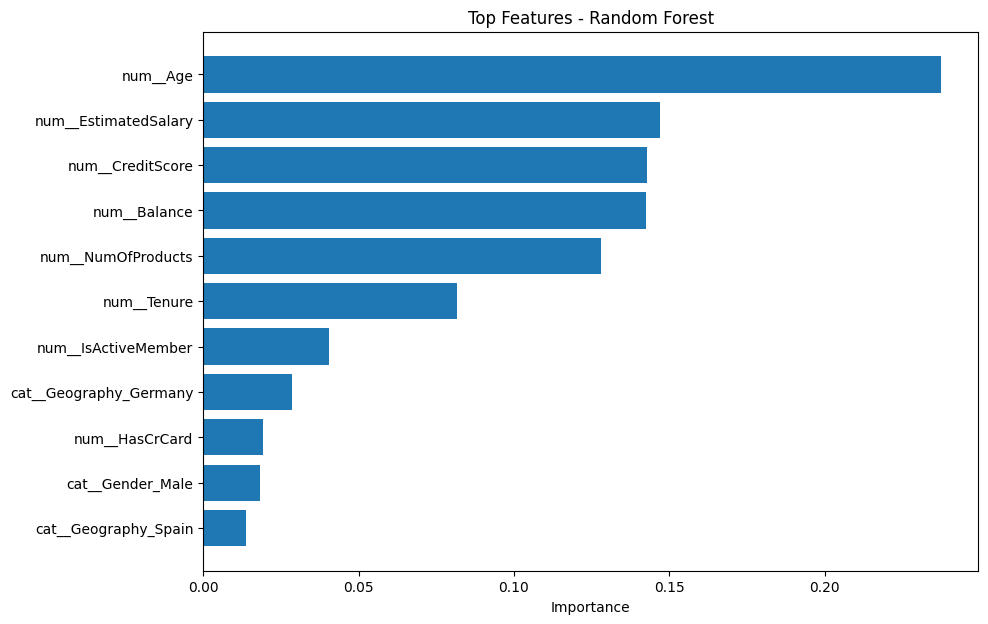

In [106]:
top_features = rf_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top Features - Random Forest")
plt.xlabel("Importance")

plt.show()

In [107]:
gb_preprocessor = gradient_boosting_model.named_steps["preprocessor"]

gb_classifier = gradient_boosting_model.named_steps["classifier"]

gb_feature_names = gb_preprocessor.get_feature_names_out()

gb_importances = gb_classifier.feature_importances_

gb_importance = pd.DataFrame({
    "Feature": gb_feature_names,
    "Importance": gb_importances
})

gb_importance = gb_importance.sort_values(
    "Importance",
    ascending=False
)

gb_importance.head(20)

,Feature,Importance
1,num__Age,0.393977
4,num__NumOfProducts,0.298257
6,num__IsActiveMember,0.115102
3,num__Balance,0.086525
8,cat__Geography_Germany,0.052130
0,num__CreditScore,0.019414
7,num__EstimatedSalary,0.016274
10,cat__Gender_Male,0.012939
2,num__Tenure,0.004224
5,num__HasCrCard,0.000633


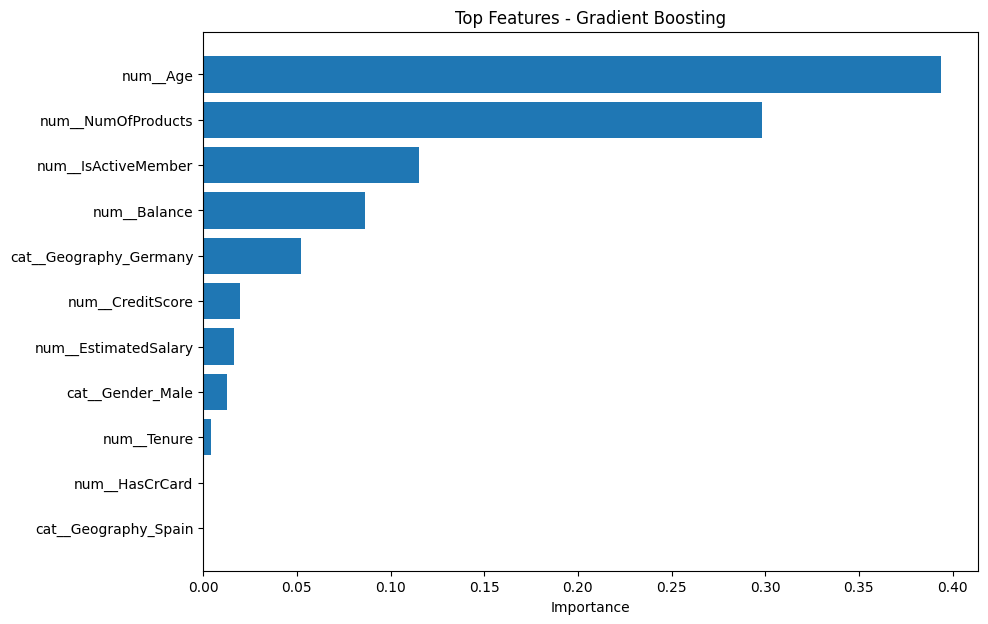

In [108]:
top_gb_features = gb_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_gb_features["Feature"][::-1],
    top_gb_features["Importance"][::-1]
)

plt.title("Top Features - Gradient Boosting")
plt.xlabel("Importance")

plt.show()

In [109]:
new_customer = pd.DataFrame({
    "CreditScore": [650],
    "Geography": ["France"],
    "Gender": ["Female"],
    "Age": [45],
    "Tenure": [3],
    "Balance": [75000],
    "NumOfProducts": [1],
    "HasCrCard": [1],
    "IsActiveMember": [0],
    "EstimatedSalary": [60000]
})

In [110]:
churn_probability = gradient_boosting_model.predict_proba(
    new_customer
)[:, 1][0]

churn_prediction = gradient_boosting_model.predict(
    new_customer
)[0]

print(
    f"Churn probability: {churn_probability:.2%}"
)

print(
    "Prediction:",
    "Customer will churn" if churn_prediction == 1
    else "Customer will stay"
)

Churn probability: 52.46%
Prediction: Customer will churn


In [111]:
df_predictions = df.copy()

df_predictions["Churn_Probability"] = gradient_boosting_model.predict_proba(
    X
)[:, 1]

df_predictions["Predicted_Churn"] = gradient_boosting_model.predict(X)

df_predictions.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Churn_Probability,Predicted_Churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.289624,0
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.215905,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0.945014,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.050452,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.150368,0


In [112]:
high_risk_customers = df_predictions[
    df_predictions["Churn_Probability"] >= 0.50
].copy()

print(
    "Number of high-risk customers:",
    len(high_risk_customers)
)

Number of high-risk customers: 1253


In [113]:
high_risk_customers = high_risk_customers.sort_values(
    "Churn_Probability",
    ascending=False
)

high_risk_customers[
    [
        "CustomerId",
        "Surname",
        "Geography",
        "Gender",
        "Age",
        "Balance",
        "NumOfProducts",
        "IsActiveMember",
        "Churn_Probability"
    ]
].head(20)

,CustomerId,Surname,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Churn_Probability
2614,15640846,Chibueze,Germany,Female,58,106458.31,4,0,0.992262
2495,15666548,Chung,Germany,Female,56,111920.13,3,0,0.990990
5950,15806808,Hope,Germany,Female,57,112281.60,3,0,0.990033
8923,15570002,Burlingame,Germany,Female,55,118772.71,4,0,0.989969
70,15703793,Konovalova,Germany,Male,58,133745.44,4,0,0.989514
4992,15783019,Price,France,Female,62,123681.32,3,0,0.989425
3549,15647725,Napolitano,France,Female,61,62055.17,3,0,0.989280
1962,15692416,Aikenhead,Spain,Female,52,143542.36,3,0,0.987652
4013,15653776,Salier,Germany,Female,57,162082.31,4,0,0.986944
9438,15641175,Munro,Germany,Male,63,120916.52,3,0,0.985814


In [114]:
output_file = "customer_churn_predictions.csv"

df_predictions.to_csv(
    output_file,
    index=False
)

print(f"Predictions saved to {output_file}")

Predictions saved to customer_churn_predictions.csv


In [115]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("Churn_Modelling.csv")

features = [
    "CreditScore", "Geography", "Gender", "Age", "Tenure",
    "Balance", "NumOfProducts", "HasCrCard",
    "IsActiveMember", "EstimatedSalary"
]

X = df[features]
y = df["Exited"]

numeric_features = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember",
    "EstimatedSalary"
]

categorical_features = ["Geography", "Gender"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

joblib.dump(model, "customer_churn_model.pkl")

print("customer_churn_model.pkl created successfully")

customer_churn_model.pkl created successfully
